# 09e - Error analysis (tuned XGBoost alone)

Calibration and error analysis for tuned XGBoost alone.

Sections: calibration, subgroup calibration (by line), accuracy near the OTP boundary, the Airport-line
miss pattern, and seasonal robustness.

## Setup

In [1]:
import time as _time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve,
)
import xgboost as xgb

from utils import (
    load_model_split, prep_gbm_matrices, GBM_FEATURES, GBM_CAT_FEATURES,
)

BASEPATH = "../data"

# temporary progress instrumentation # Claude
PROGRESS_LOG = "/tmp/09e_progress.log"

def log_progress(msg):
    ts = _time.strftime("%H:%M:%S")
    line = f"[{ts}] {msg}"
    print(line)
    with open(PROGRESS_LOG, "a") as f:
        f.write(line + "\n")

log_progress("09e_error_analysis.ipynb started")

train_df, test_df = load_model_split(BASEPATH)

# kept only for the complete-case mask, matching every other notebook
logit_predictor_cols = [
    "line", "wx_primary_asof_collapsed", "temp_c_asof",
    "wind_speed_ms_asof", "precip_mm_asof", "any_gust_24h",
    "any_ice_24h", "has_cloud_layer", "am_peak_overlap_bin",
    "pm_peak_x_sports", "day_of_week", "is_holiday",
    "sched_duration_sec", "is_inbound", "lag_line_lateness_min",
    "lag_network_lateness_2hr_mean", "lag_train_lateness_5run_mean",
]

VAL_YEAR = 2024
train_sub = train_df[train_df["year"] < VAL_YEAR].copy()
val_df = train_df[train_df["year"] == VAL_YEAR].copy()

val_mask = val_df[logit_predictor_cols].notna().all(axis = 1)
test_mask = test_df[logit_predictor_cols].notna().all(axis = 1)
val_cc = val_df[val_mask].copy()
test_cc = test_df[test_mask].copy()
y_val_cc, y_test_cc = val_cc["is_otp"], test_cc["is_otp"]

print(f"val: {val_cc.shape}, test: {test_cc.shape}")

[17:05:15] 09e_error_analysis.ipynb started


val: (186483, 107), test: (125836, 107)


## 0. Rebuild the stacked lateness feature + fit tuned XGBoost

Same idea as `09b` -> `09d`. `TUNED_XGB_PARAMS` is `09c`'s best

In [2]:
TUNED_REG_PARAMS = dict(
    min_samples_leaf = 10, max_leaf_nodes = 127, max_iter = 500,
    max_depth = 7, learning_rate = 0.03, l2_regularization = 1,
)
TUNED_XGB_PARAMS = dict(
    subsample = 1.0, reg_lambda = 2, n_estimators = 400,
    min_child_weight = 3, max_depth = 7, learning_rate = 0.03,
    colsample_bytree = 0.6,
)

X_train_sub_gbm, X_val_gbm = prep_gbm_matrices(train_sub, val_df)
_, X_test_gbm_base = prep_gbm_matrices(train_sub, test_df)
y_train_sub_log = np.log1p(train_sub["lateness"])

_t0 = _time.time()
log_progress(
    "Rebuilding out-of-fold stacked lateness feature on "
    "train_sub (5-fold KFold)..."
)
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
oof_pred_lateness = np.zeros(len(train_sub))
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_sub_gbm), start = 1):
    fold_reg = HistGradientBoostingRegressor(
        categorical_features = "from_dtype", random_state = 42,
        **TUNED_REG_PARAMS
    )
    fold_reg.fit(X_train_sub_gbm.iloc[tr_idx], y_train_sub_log.iloc[tr_idx])
    oof_pred_lateness[val_idx] = np.expm1(
        fold_reg.predict(X_train_sub_gbm.iloc[val_idx])
    )
    log_progress(f"  fold {fold}/5 done")

train_sub["pred_lateness_gbm"] = oof_pred_lateness
reg_full = HistGradientBoostingRegressor(
    categorical_features = "from_dtype", random_state = 42,
    **TUNED_REG_PARAMS
)
reg_full.fit(X_train_sub_gbm, y_train_sub_log)
val_df["pred_lateness_gbm"] = np.expm1(reg_full.predict(X_val_gbm))
test_df["pred_lateness_gbm"] = np.expm1(reg_full.predict(X_test_gbm_base))

STACKED_FEATURES = GBM_FEATURES + ["pred_lateness_gbm"]
val_cc = val_df[val_mask].copy()
test_cc = test_df[test_mask].copy()
log_progress(f"Stacked feature rebuilt ({_time.time() - _t0:.1f}s total)")

X_train_sub_stacked, X_val_stacked = prep_gbm_matrices(
    train_sub, val_df,
    features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
)
_, X_test_stacked = prep_gbm_matrices(
    train_sub, test_df,
    features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
)

_t0 = _time.time()
log_progress("Fitting tuned XGBoost (train_sub)...")
gbm = xgb.XGBClassifier(
    random_state = 42, enable_categorical = True,
    tree_method = "hist", **TUNED_XGB_PARAMS
)
gbm.fit(X_train_sub_stacked, train_sub["is_otp"])
p_otp_val = gbm.predict_proba(X_val_stacked)[:, 1][val_mask.values]
p_otp_test = gbm.predict_proba(X_test_stacked)[:, 1][test_mask.values]
val_cc["p_otp"] = p_otp_val
test_cc["p_otp"] = p_otp_test
log_progress(f"Tuned XGBoost fit complete ({_time.time() - _t0:.1f}s)")
print(f"test ROC-AUC: {roc_auc_score(y_test_cc, p_otp_test):.4f}")

[17:05:19] Rebuilding out-of-fold stacked lateness feature on train_sub (5-fold KFold)...


[17:06:06]   fold 1/5 done


[17:06:57]   fold 2/5 done


[17:07:42]   fold 3/5 done


[17:08:31]   fold 4/5 done


[17:09:19]   fold 5/5 done


[17:10:15] Stacked feature rebuilt (296.8s total)


[17:10:17] Fitting tuned XGBoost (train_sub)...


[17:10:42] Tuned XGBoost fit complete (24.9s)
test ROC-AUC: 0.8045


## 1. Calibration

Predicted probability deciles vs. observed OTP rate

                               mean_predicted  mean_actual      n
decile                                                           
(0.019799999999999998, 0.472]        0.253606     0.269151  12584
(0.472, 0.666]                       0.580963     0.602432  12584
(0.666, 0.766]                       0.720735     0.733132  12583
(0.766, 0.825]                       0.797184     0.796408  12584
(0.825, 0.867]                       0.846669     0.841294  12583
(0.867, 0.899]                       0.883811     0.878497  12584
(0.899, 0.926]                       0.913034     0.899547  12583
(0.926, 0.947]                       0.936545     0.926573  12584
(0.947, 0.966]                       0.956405     0.949456  12583
(0.966, 0.993]                       0.976261     0.970121  12584


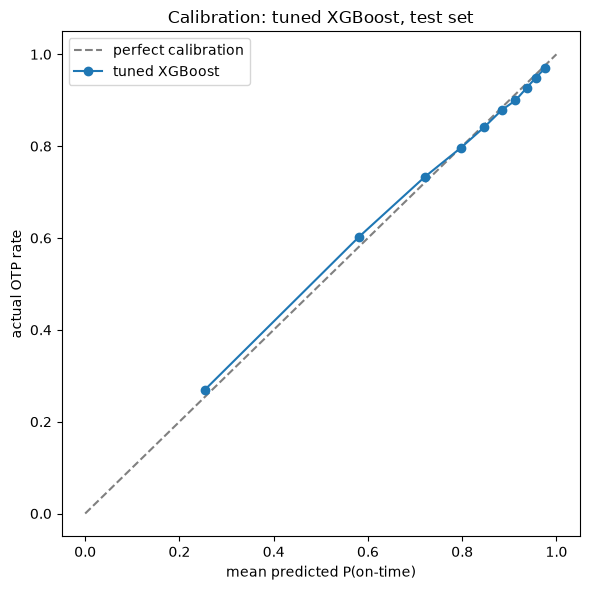

In [3]:
calib = pd.DataFrame({"p_otp": p_otp_test, "is_otp": y_test_cc.values})
calib["decile"] = pd.qcut(calib["p_otp"], 10, duplicates = "drop")
calib_summary = calib.groupby("decile", observed = True).agg(
    mean_predicted = ("p_otp", "mean"),
    mean_actual = ("is_otp", "mean"),
    n = ("is_otp", "size"),
)
print(calib_summary)

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(
    [0, 1], [0, 1], linestyle = "--", color = "gray",
    label = "perfect calibration",
)
ax.plot(
    calib_summary["mean_predicted"], calib_summary["mean_actual"],
    marker = "o", label = "tuned XGBoost",
)
ax.set_xlabel("mean predicted P(on-time)")
ax.set_ylabel("actual OTP rate")
ax.set_title("Calibration: tuned XGBoost, test set")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Subgroup calibration (by line)

Positive `gap` means the model is too optimistic for that line.

In [4]:
by_line = test_cc.groupby("line", observed = True).agg(
    mean_predicted = ("p_otp", "mean"),
    actual_otp = ("is_otp", "mean"),
    n = ("is_otp", "size"),
)
by_line["gap"] = by_line["mean_predicted"] - by_line["actual_otp"]
print(by_line.sort_values("gap"))

                     mean_predicted  actual_otp      n       gap
line                                                            
Wilmington/Newark          0.740307    0.777927   8182 -0.037620
Paoli/Thorndale            0.779661    0.811838  12755 -0.032177
Chestnut Hill East         0.801369    0.830192   4988 -0.028823
Manayunk/Norristown        0.800302    0.824072  11266 -0.023770
Chestnut Hill West         0.804563    0.817234   8344 -0.012671
West Trenton               0.695413    0.704678   8252 -0.009265
Warminster                 0.802021    0.809236  11585 -0.007215
Fox Chase                  0.808391    0.806576   7755  0.001815
Lansdale/Doylestown        0.714001    0.708800  11614  0.005202
Trenton                    0.775950    0.760213  10697  0.015737
Cynwyd                     0.909471    0.884184   1960  0.025288
Media/Wawa                 0.782247    0.754634  10735  0.027613
Airport                    0.857039    0.812461  17703  0.044578


Wilmington and Paoli underconfident, Airport over

## 3. Accuracy near the OTP boundary

`is_otp` is `lateness < 6` - runs finishing close to that cutoff should be the hardest to predict correctly. Evaluated at the F1-maximizing threshold.

In [5]:
# F1-maximizing threshold, computed here (not reused from a separate
# threshold-selection section) since this is the only place it's used
p_late_val = 1 - p_otp_val
y_late_val = 1 - y_val_cc
precision, recall, pr_thresholds = precision_recall_curve(
    y_late_val, p_late_val
)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
f1_threshold_late = pr_thresholds[f1_scores[:-1].argmax()]
f1_threshold = 1 - f1_threshold_late

pred_late_f1 = (p_otp_test < f1_threshold).astype(int)

lateness_bins = [-1, 0, 3, 5, 6, 9, 15, 30, np.inf]
lateness_labels = [
    "0 (perfectly on time)", "1-3", "4-5 (still OTP)", "6 (just late)",
    "7-9", "10-15", "16-30", "30+",
]
test_cc["lateness_bin"] = pd.cut(
    test_cc["lateness"], bins = lateness_bins, labels = lateness_labels
)
test_cc["correct_f1"] = (
    test_cc["is_otp"].values == (1 - pred_late_f1)
).astype(int)

by_lateness = test_cc.groupby("lateness_bin", observed = True).agg(
    accuracy = ("correct_f1", "mean"), n = ("correct_f1", "size"),
)
print(by_lateness)

                       accuracy      n
lateness_bin                          
0 (perfectly on time)  0.891524  52325
1-3                    0.801366  33967
4-5 (still OTP)        0.642857  12698
6 (just late)          0.456076   4337
7-9                    0.535242   8243
10-15                  0.653982   6780
16-30                  0.746109   4754
30+                    0.777818   2732


Reaaallly rough as we approach the threshold, better on edges of range. Inherent issue with continuous -> binary

In [6]:
# quick comparison: default 0.5 vs. two threshold-selection methods
# (both fit on val, evaluated here on test) -- illustrates the
# tradeoff, not a full analysis
fpr, tpr, roc_thresholds = roc_curve(1 - y_val_cc, 1 - p_otp_val)
youden_threshold = 1 - roc_thresholds[(tpr - fpr).argmax()]

y_late_test = 1 - y_test_cc.values
pred_late_default = (p_otp_test < 0.5).astype(int)
pred_late_youden = (p_otp_test < youden_threshold).astype(int)

for name, pred_late in [
    ("default (0.500)", pred_late_default),
    (f"Youden's J ({youden_threshold:.3f})", pred_late_youden),
    (f"F1-maximizing ({f1_threshold:.3f})", pred_late_f1),
]:
    tp = ((y_late_test == 1) & (pred_late == 1)).sum()
    fn = ((y_late_test == 1) & (pred_late == 0)).sum()
    fp = ((y_late_test == 0) & (pred_late == 1)).sum()
    print(
        f"{name}: caught {tp:,}/{tp + fn:,} delays "
        f"(recall={tp / (tp + fn):.1%}), "
        f"{fp:,} false alarms (precision={tp / (tp + fp):.1%})"
    )

default (0.500): caught 9,823/26,846 delays (recall=36.6%), 4,097 false alarms (precision=70.6%)
Youden's J (0.814): caught 19,659/26,846 delays (recall=73.2%), 28,023 false alarms (precision=41.2%)
F1-maximizing (0.738): caught 16,496/26,846 delays (recall=61.4%), 16,958 false alarms (precision=49.3%)


## 4. Airport-line miss pattern

Every Airport run where tuned XGBoost was confident (P(on-time) >= 0.9) but wrong - checks whether misses cluster by time of day, day of week, direction, first/last run status, or month.

In [7]:
airport_all = test_cc[test_cc["line"] == "Airport"].copy()
airport_misses = airport_all[
    (airport_all["is_otp"] == 0) & (airport_all["p_otp"] >= 0.9)
].copy()
print(
    f"Airport rows: {len(airport_all):,}, "
    f"confident-and-wrong misses: {len(airport_misses):,} "
    f"({len(airport_misses) / len(airport_all):.2%})"
)

airport_all["sched_hour"] = (airport_all["sched_origin_sec"] // 3600) % 24
airport_misses["sched_hour"] = (
    airport_misses["sched_origin_sec"] // 3600
) % 24

def compare_share(all_df, miss_df, col):
    all_share = all_df[col].value_counts(normalize = True, dropna = False)
    miss_share = miss_df[col].value_counts(normalize = True, dropna = False)
    out = pd.DataFrame({
        "share_of_all_airport": all_share, "share_of_misses": miss_share,
    }).fillna(0)
    out["skew"] = out["share_of_misses"] - out["share_of_all_airport"]
    return out.sort_values("skew", ascending = False)

compare_cols = [
    "sched_hour", "day_of_week", "is_inbound",
    "is_first_run_of_day", "is_last_run_of_day", "month",
]
for col in compare_cols:
    print(f"\n--- {col} ---")
    print(compare_share(airport_all, airport_misses, col))

Airport rows: 17,703, confident-and-wrong misses: 798 (4.51%)

--- sched_hour ---
            share_of_all_airport  share_of_misses      skew
sched_hour                                                 
13.0                    0.051799         0.070175  0.018376
14.0                    0.051460         0.066416  0.014956
12.0                    0.052082         0.066416  0.014334
8.0                     0.051912         0.063910  0.011998
6.0                     0.052025         0.062657  0.010632
15.0                    0.051517         0.057644  0.006127
7.0                     0.051856         0.057644  0.005788
11.0                    0.051686         0.056391  0.004705
22.0                    0.050556         0.053885  0.003328
9.0                     0.051404         0.050125 -0.001278
21.0                    0.050726         0.048872 -0.001854
20.0                    0.050782         0.048872 -0.001910
4.0                     0.021013         0.017544 -0.003470
19.0              

## 5. Seasonal robustness

Full-year 2024 (`val`) alongside 2025 (`test`), plus a monthly breakdown of each to see whether performance drifts within a year or is specific to late-2025.

In [8]:
def evaluate(name, y_true, p_otp, threshold = 0.5):
    y_late = 1 - y_true
    p_late = 1 - p_otp
    pred = (p_otp >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": (pred == y_true).mean(),
        "roc_auc": roc_auc_score(y_true, p_otp),
        "pr_auc_late": average_precision_score(y_late, p_late),
        "brier": brier_score_loss(y_true, p_otp),
    }

seasonal_check = pd.DataFrame([
    evaluate("2024 (full year, val)", val_cc["is_otp"], val_cc["p_otp"]),
    evaluate("2025 Jan-Aug (test)", test_cc["is_otp"], test_cc["p_otp"]),
]).set_index("model")
print(seasonal_check)

                       accuracy   roc_auc  pr_auc_late     brier
model                                                           
2024 (full year, val)  0.847316  0.817925     0.598749  0.113616
2025 Jan-Aug (test)    0.832162  0.804500     0.610259  0.124046


In [9]:
by_month_test = pd.DataFrame([
    evaluate(f"2025-{int(m):02d}", sub["is_otp"], sub["p_otp"])
    for m, sub in test_cc.groupby("month", observed = True)
]).set_index("model")
print("=== 2025 (test) by month ===")
print(by_month_test)

by_month_val = pd.DataFrame([
    evaluate(f"2024-{int(m):02d}", sub["is_otp"], sub["p_otp"])
    for m, sub in val_cc.groupby("month", observed = True)
]).set_index("model")
print("\n=== 2024 (val) by month ===")
print(by_month_val)
log_progress("09e_error_analysis.ipynb complete")

=== 2025 (test) by month ===
         accuracy   roc_auc  pr_auc_late     brier
model                                             
2025-01  0.817324  0.816235     0.642365  0.130426
2025-02  0.825189  0.828196     0.692319  0.126831
2025-03  0.855705  0.808858     0.578142  0.109216
2025-04  0.851324  0.797832     0.563478  0.113020
2025-05  0.827729  0.787399     0.572380  0.128534
2025-06  0.815104  0.811605     0.650308  0.133161
2025-07  0.828498  0.809573     0.631042  0.125665
2025-08  0.835694  0.745516     0.482296  0.126635



=== 2024 (val) by month ===
         accuracy   roc_auc  pr_auc_late     brier
model                                             
2024-01  0.846983  0.839703     0.643866  0.112070
2024-02  0.873560  0.823030     0.548973  0.097096
2024-03  0.859395  0.831555     0.602376  0.105528
2024-04  0.863354  0.809129     0.550652  0.104472
2024-05  0.864892  0.805840     0.539583  0.103123
2024-06  0.849285  0.810419     0.577911  0.113764
2024-07  0.840608  0.800800     0.581467  0.119736
2024-08  0.853765  0.822936     0.617726  0.109877
2024-09  0.856054  0.803720     0.537770  0.108192
2024-10  0.837119  0.811996     0.590919  0.119260
2024-11  0.816058  0.799456     0.600296  0.132694
2024-12  0.813390  0.825554     0.695579  0.133640
[17:10:42] 09e_error_analysis.ipynb complete
